In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
np.random.seed(42)

n = 300

# base variables
study_hours = np.random.normal(5, 2, n).clip(1, 12)
age         = np.random.randint(18, 30, n)
attendance  = (study_hours * 7 + np.random.normal(30, 5, n)).clip(40, 100)
marks       = (study_hours * 6 + np.random.normal(30, 8, n)).clip(20, 100)
fees_paid   = np.random.exponential(50000, n)

df = pd.DataFrame({
    "study_hours" : study_hours,
    "attendance"  : attendance,
    "marks"       : marks,
    "age"         : age,
    "fees_paid"   : fees_paid,
    "gender"      : np.random.choice(["Male","Female"], n, p=[0.55,0.45]),
    "grade"       : pd.cut(marks,
                           bins=[0,40,55,70,100],
                           labels=["D","C","B","A"]),
    "city"        : np.random.choice(["Mumbai","Delhi","Surat","Pune"], n)
})

print(df.shape)
print(df.head())

(300, 8)
   study_hours  attendance      marks  age      fees_paid  gender grade  \
0     5.993428   77.567387  76.691065   26   49923.900011    Male     A   
1     4.723471   55.858321  51.270606   21   66046.500756  Female     C   
2     6.295377   73.453083  72.363998   27    7053.281485  Female     A   
3     8.046060   85.945900  64.247769   22   62908.245456    Male     B   
4     4.531693   56.215593  73.840677   26  119862.660314  Female     A   

     city  
0   Surat  
1   Surat  
2  Mumbai  
3   Delhi  
4    Pune  


### Pair plots

>  It plots every numerical column against every other numerical column in one single grid

Generating Pair Plot...


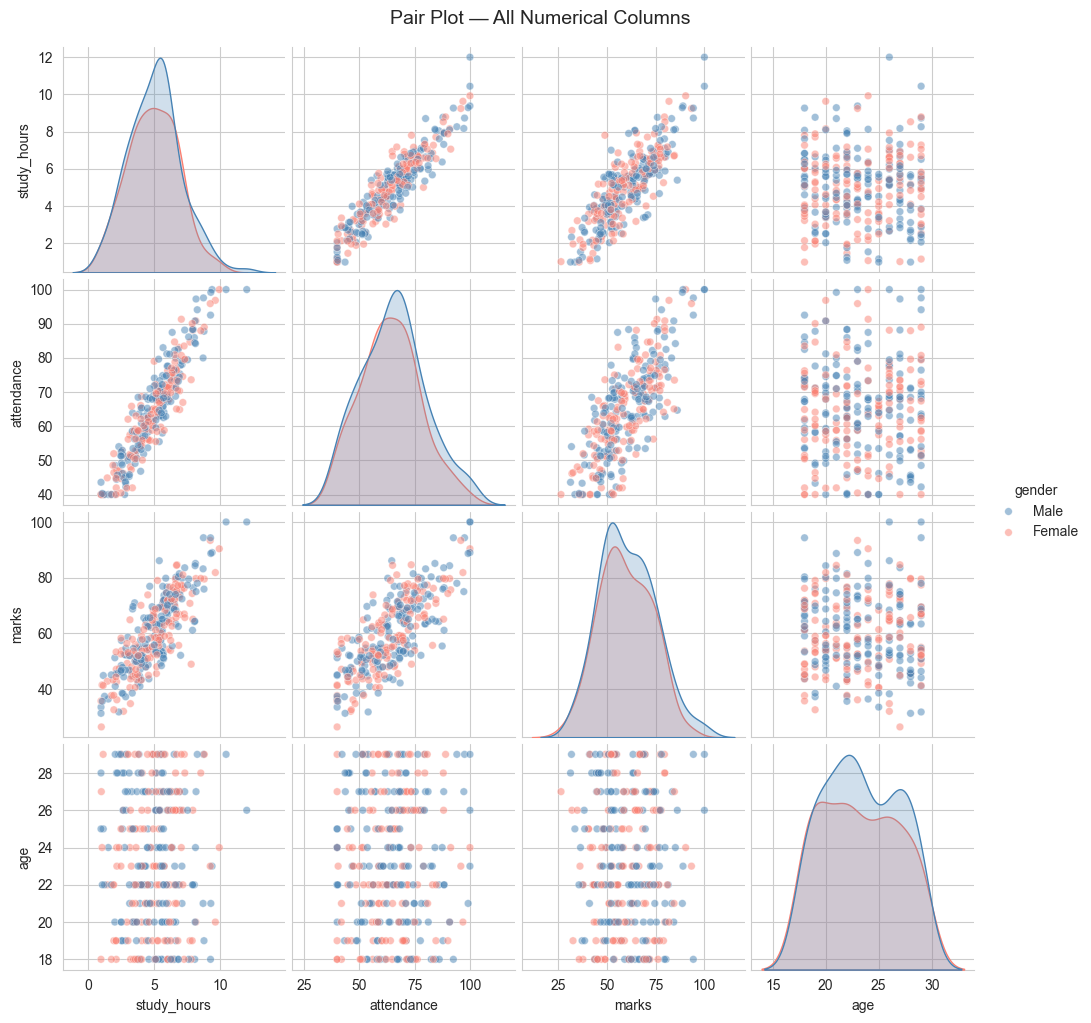

In [2]:
print("Generating Pair Plot...")

# basic pair plot
sns.pairplot(
    df[["study_hours","attendance","marks","age","gender"]],
    hue="gender",          # color points by gender (3rd variable!)
    palette={"Male":"steelblue","Female":"salmon"},
    diag_kind="kde",       # diagonal = KDE instead of histogram
    plot_kws={"alpha":0.5, "s":30}
)

plt.suptitle("Pair Plot — All Numerical Columns", y=1.02, fontsize=14)
plt.savefig("pair_plot.png", dpi=150, bbox_inches='tight')
plt.show()

### Correlation Heatmap

> It is a color-coded table showing correlation between ALL numerical columns at once

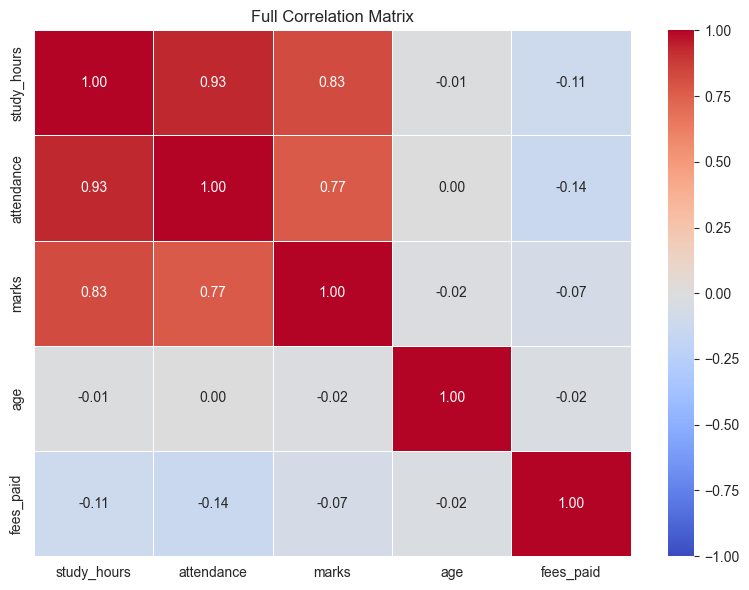

In [3]:
num_cols = ["study_hours", "attendance", "marks", "age", "fees_paid"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    linewidths=0.5,
    vmin=-1, vmax=1
)
ax.set_title("Full Correlation Matrix")
plt.tight_layout()
plt.savefig("heatmap_full.png", dpi=150)
plt.show()

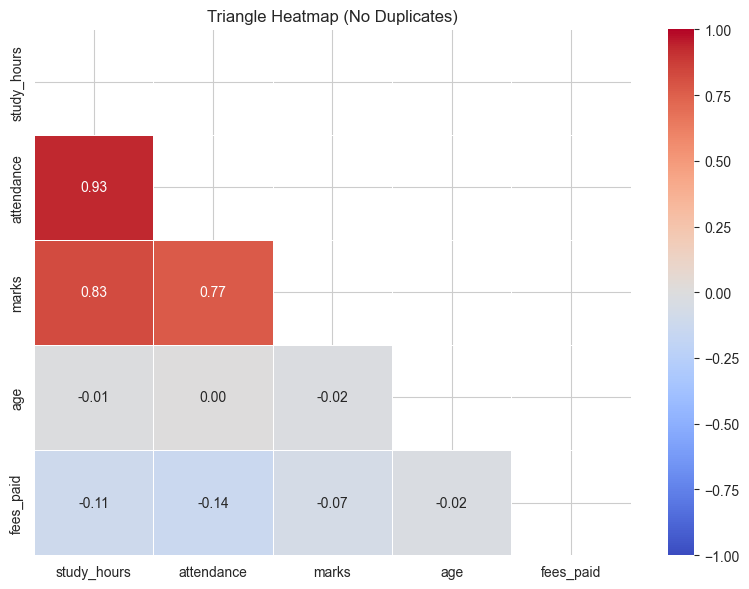

In [4]:
num_cols = ["study_hours", "attendance", "marks", "age", "fees_paid"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1
)
ax.set_title("Triangle Heatmap (No Duplicates)")
plt.tight_layout()
plt.savefig("heatmap_triangle.png", dpi=150)
plt.show()

### Scatter plots with hue

> A scatter plot between 2 numerical columns, colored by a 3rd categorical variable - so you see variables in one plot

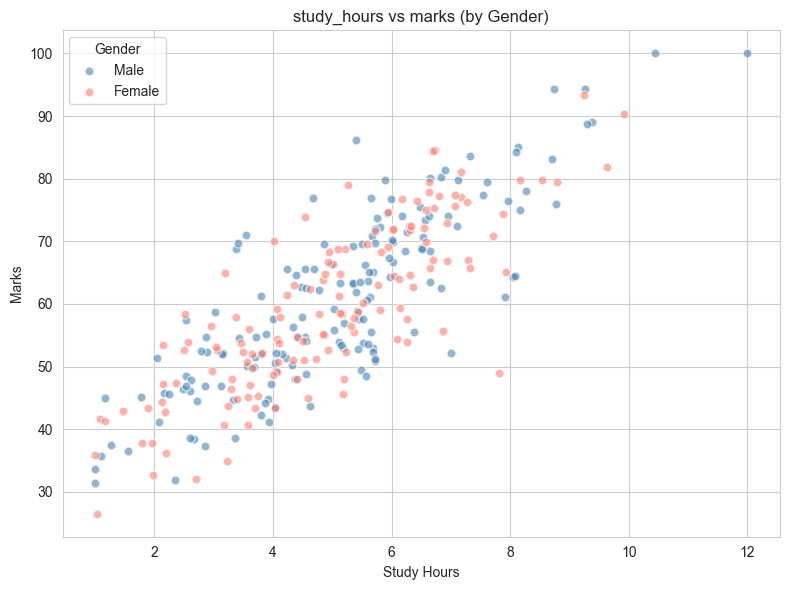

In [5]:
# Plot 1: study_hours vs marks (by Gender)
fig, ax = plt.subplots(figsize=(8, 6))

for gender, color in [("Male", "steelblue"), ("Female", "salmon")]:
    subset = df[df["gender"] == gender]
    ax.scatter(subset["study_hours"], subset["marks"],
               label=gender, color=color,
               alpha=0.6, s=40, edgecolors='white')

ax.set_title("study_hours vs marks (by Gender)")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Marks")
ax.legend(title="Gender")
plt.tight_layout()
plt.savefig("scatter_gender.png", dpi=150)
plt.show()

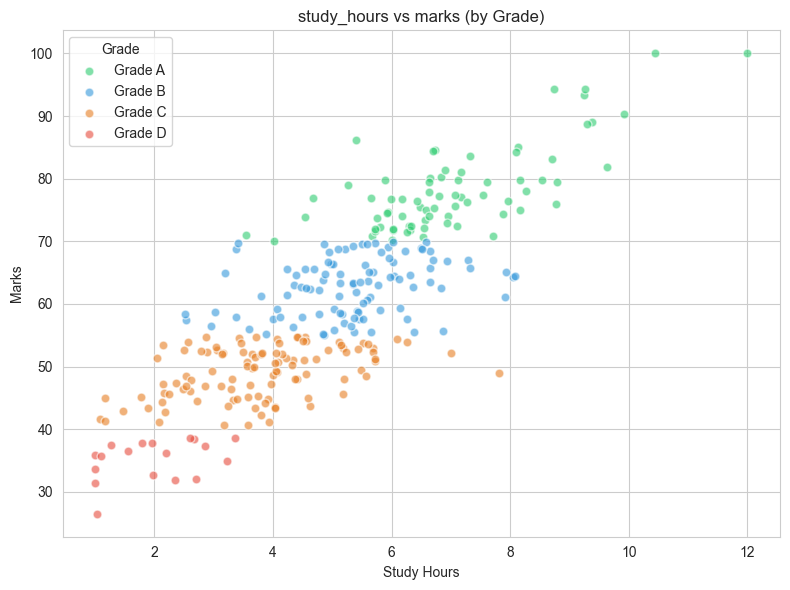

In [7]:
# Plot 2: study_hours vs marks (by Grade)
pythonfig, ax = plt.subplots(figsize=(8, 6))

palette = {"A": "#2ecc71", "B": "#3498db", "C": "#e67e22", "D": "#e74c3c"}
for grade, color in palette.items():
    subset = df[df["grade"] == grade]
    ax.scatter(subset["study_hours"], subset["marks"],
               label=f"Grade {grade}", color=color,
               alpha=0.6, s=40, edgecolors='white')

ax.set_title("study_hours vs marks (by Grade)")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Marks")
ax.legend(title="Grade")
plt.tight_layout()
plt.savefig("scatter_grade.png", dpi=150)
plt.show()

### Bubble chart

>> 4 variables in ONE single plot!

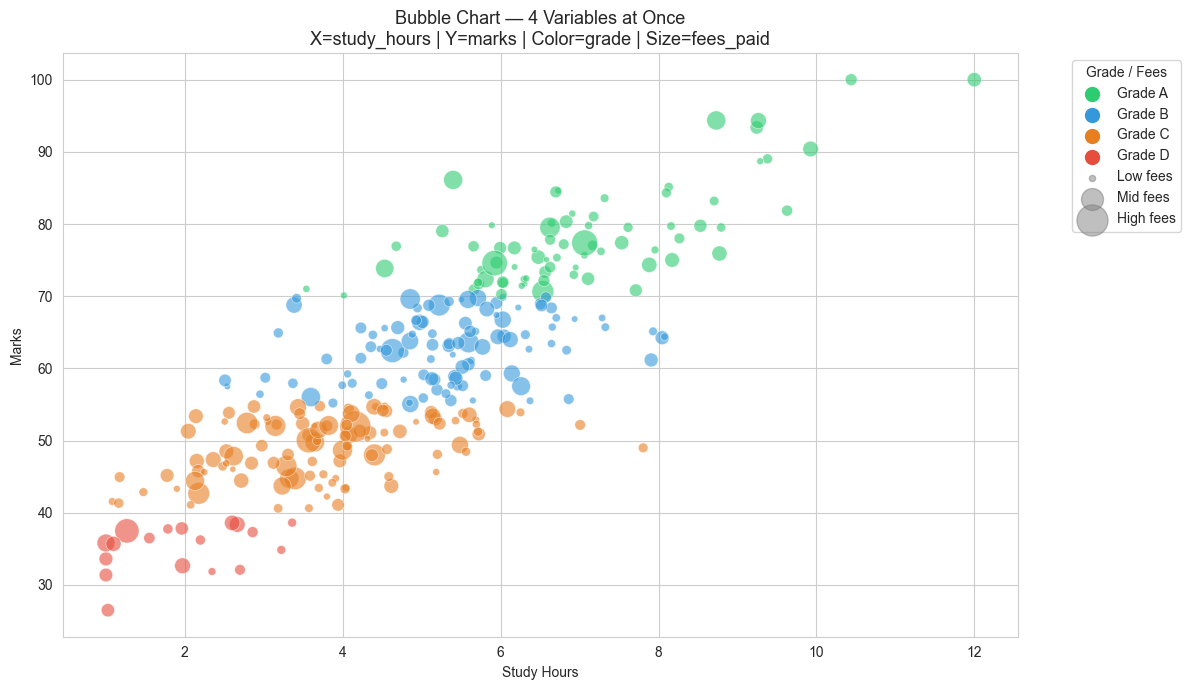

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

# normalize fees_paid to bubble size (20 to 500)
sizes = ((df["fees_paid"] - df["fees_paid"].min()) /
         (df["fees_paid"].max() - df["fees_paid"].min())) * 480 + 20

colors = df["grade"].map({"A": "#2ecc71", "B": "#3498db",
                           "C": "#e67e22", "D": "#e74c3c"})

ax.scatter(
    df["study_hours"],
    df["marks"],
    s=sizes,
    c=colors,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5
)

# legend for grade colors
for grade, color in [("A", "#2ecc71"), ("B", "#3498db"),
                     ("C", "#e67e22"), ("D", "#e74c3c")]:
    ax.scatter([], [], c=color, label=f"Grade {grade}", s=100)

# legend for bubble size
for size_val, label in [(20, "Low fees"), (250, "Mid fees"), (500, "High fees")]:
    ax.scatter([], [], s=size_val, c='gray', alpha=0.5, label=label)

ax.set_title("Bubble Chart — 4 Variables at Once\n"
             "X=study_hours | Y=marks | Color=grade | Size=fees_paid",
             fontsize=13)
ax.set_xlabel("Study Hours")
ax.set_ylabel("Marks")
ax.legend(title="Grade / Fees", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("bubble_chart.png", dpi=150)
plt.show()

### Parallel Coordinates

Each vertical line = one column. Each student = one line connecting all columns. Lines that follow similar paths = similar students.

Best for spotting overall patterns and clusters across many variables at once.

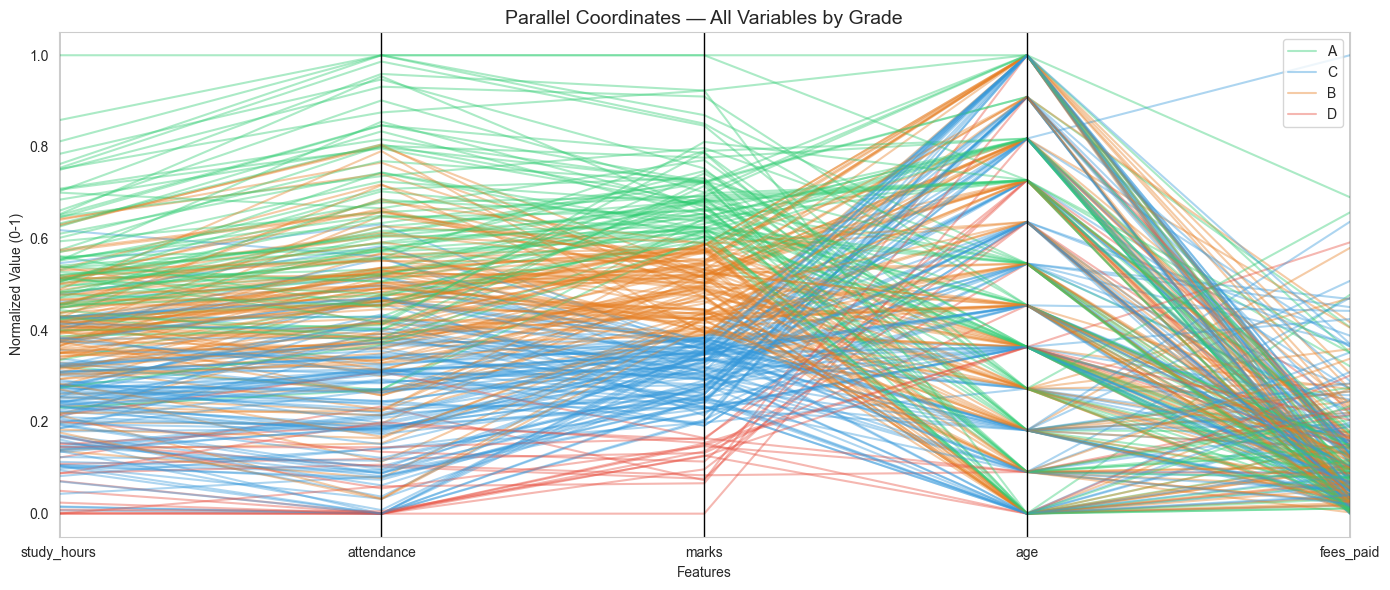

In [10]:
from pandas.plotting import parallel_coordinates

# ── PARALLEL COORDINATES ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# normalize all columns to same scale (0-1)
cols_to_plot = ["study_hours","attendance","marks","age","fees_paid","grade"]
plot_df      = df[cols_to_plot].copy()

# normalize numerical columns
for col in ["study_hours","attendance","marks","age","fees_paid"]:
    plot_df[col] = ((plot_df[col] - plot_df[col].min()) /
                    (plot_df[col].max() - plot_df[col].min()))

parallel_coordinates(
    plot_df,
    class_column="grade",   # color lines by grade
    color=["#2ecc71","#3498db","#e67e22","#e74c3c"],
    alpha=0.4,
    ax=ax
)

ax.set_title("Parallel Coordinates — All Variables by Grade", fontsize=14)
ax.set_xlabel("Features")
ax.set_ylabel("Normalized Value (0-1)")

plt.tight_layout()
plt.savefig("parallel_coords.png", dpi=150)
plt.show()

### PCA (Principle component analysis)

PCA (Principal Component Analysis) takes many columns and compresses them into 2 columns so you can visualize high-dimensional data in a 2D plot.

> It doesn't drop columns — it combines them into new components that capture maximum variance.

In [11]:
num_cols = ["study_hours", "attendance", "marks", "age", "fees_paid"]

# Step 1: scale the data
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

# Step 2: apply PCA
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 3: variance explained
print("Variance explained by each component:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Step 4: build PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["grade"]  = df["grade"].values
pca_df["gender"] = df["gender"].values

Variance explained by each component:
  PC1: 54.1%
  PC2: 20.4%
  Total: 74.5%


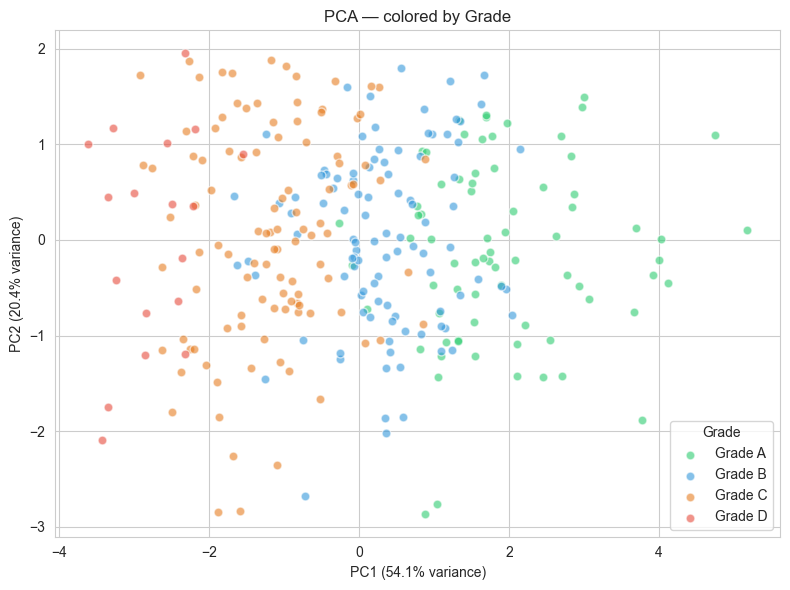

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

palette = {"A": "#2ecc71", "B": "#3498db", "C": "#e67e22", "D": "#e74c3c"}
for grade, color in palette.items():
    subset = pca_df[pca_df["grade"] == grade]
    ax.scatter(subset["PC1"], subset["PC2"],
               label=f"Grade {grade}", color=color,
               alpha=0.6, s=40, edgecolors='white')

ax.set_title("PCA — colored by Grade")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(title="Grade")
plt.tight_layout()
plt.savefig("pca_grade.png", dpi=150)
plt.show()

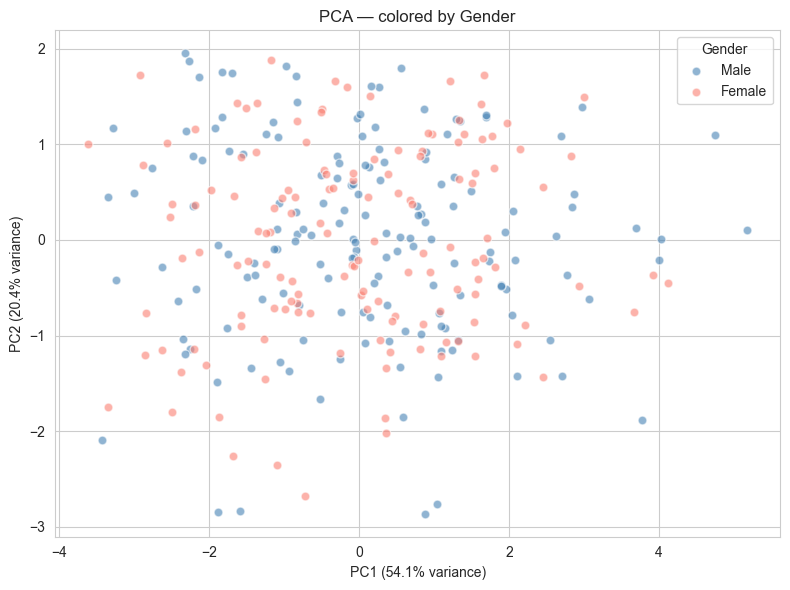

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for gender, color in [("Male", "steelblue"), ("Female", "salmon")]:
    subset = pca_df[pca_df["gender"] == gender]
    ax.scatter(subset["PC1"], subset["PC2"],
               label=gender, color=color,
               alpha=0.6, s=40, edgecolors='white')

ax.set_title("PCA — colored by Gender")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(title="Gender")
plt.tight_layout()
plt.savefig("pca_gender.png", dpi=150)
plt.show()